In [26]:
import matplotlib.pyplot as plt
from pandas import DataFrame
from common.utils import load_dataset, optimize_memory, get_params, DatasetType
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns
from plotnine import ggplot, aes, geom_histogram, scale_x_log10, scale_y_sqrt
import pandas as pd

In [27]:
df: DataFrame = load_dataset("nyc-taxi-trip-duration", DatasetType.TRAIN, index=True)
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [28]:
df.dtypes

id                     object
vendor_id               int64
pickup_datetime        object
dropoff_datetime       object
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag     object
trip_duration           int64
dtype: object

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [30]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


#### Missing values

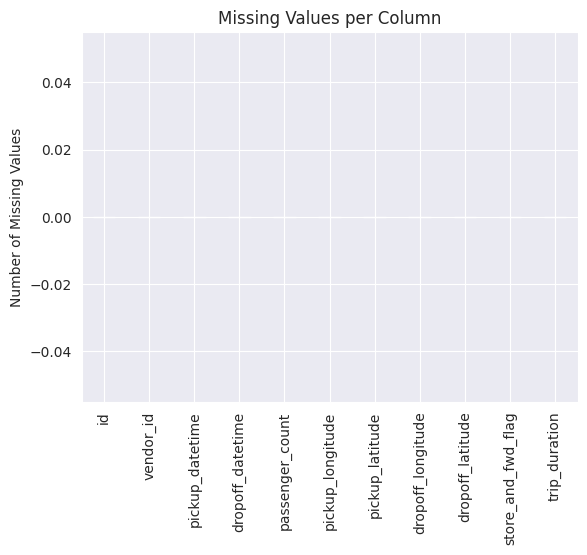

In [31]:
missing_counts = df.isna().sum()
missing_counts.plot(kind='bar')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Column')
plt.show()

In [32]:
df, na_list = optimize_memory(df, deep=True)
df.dtypes

Memory usage of properties dataframe is : 417.3215217590332  MB
******************************
Column:  vendor_id
dtype before:  int64
dtype after:  uint8
******************************
******************************
Column:  passenger_count
dtype before:  int64
dtype after:  uint8
******************************
******************************
Column:  pickup_longitude
dtype before:  float64
dtype after:  float32
******************************
******************************
Column:  pickup_latitude
dtype before:  float64
dtype after:  float32
******************************
******************************
Column:  dropoff_longitude
dtype before:  float64
dtype after:  float32
******************************
******************************
Column:  dropoff_latitude
dtype before:  float64
dtype after:  float32
******************************
******************************
Column:  trip_duration
dtype before:  int64
dtype after:  uint32
******************************
___MEMORY USAGE AFTER COMPL

id                     object
vendor_id               uint8
pickup_datetime        object
dropoff_datetime       object
passenger_count         uint8
pickup_longitude      float32
pickup_latitude       float32
dropoff_longitude     float32
dropoff_latitude      float32
store_and_fwd_flag     object
trip_duration          uint32
dtype: object

In [33]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [34]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [35]:
df.dtypes

id                            object
vendor_id                      uint8
pickup_datetime       datetime64[ns]
dropoff_datetime      datetime64[ns]
passenger_count                uint8
pickup_longitude             float32
pickup_latitude              float32
dropoff_longitude            float32
dropoff_latitude             float32
store_and_fwd_flag            object
trip_duration                 uint32
dtype: object

##### Validate the trip duration with the pickup and drop off time

In [36]:
df['check'] = ((df['dropoff_datetime'] - df['pickup_datetime']).dt.total_seconds()
               + df['trip_duration']).abs() > 0

result = df[['check', 'pickup_datetime', 'dropoff_datetime', 'trip_duration']] \
    .groupby('check') \
    .size() \
    .reset_index(name='n')

print(result)

   check        n
0   True  1458644


##### Trip duration plot

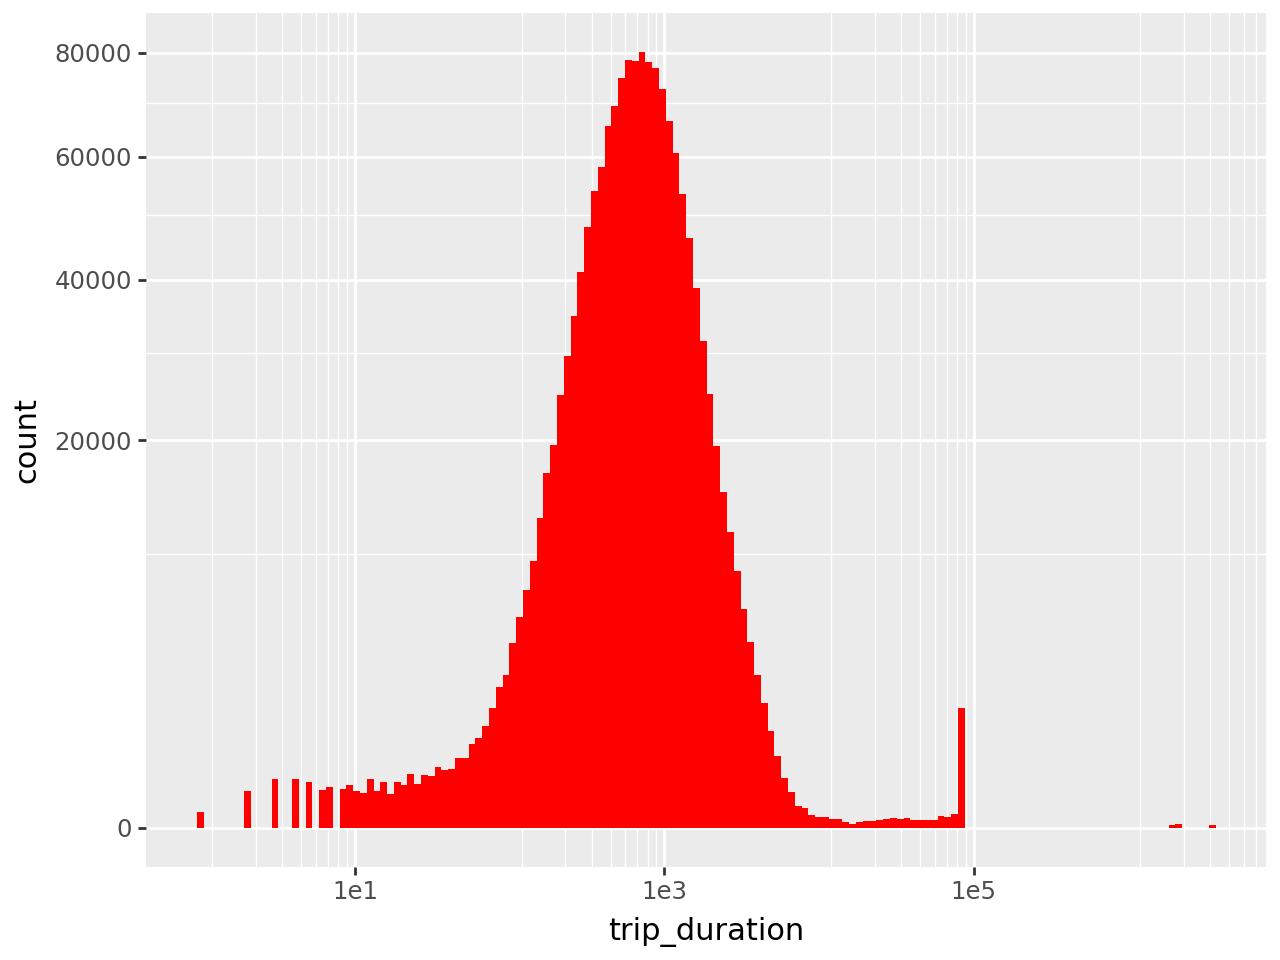

In [37]:
(
    ggplot(df, aes(x='trip_duration'))
    + geom_histogram(fill='red', bins=150)
    + scale_x_log10()
    + scale_y_sqrt()
)

In [38]:
df_sorted = df.sort_values('trip_duration', ascending=False)

cols = ['trip_duration', 'pickup_datetime', 'dropoff_datetime'] + \
       [col for col in df.columns if col not in ['trip_duration', 'pickup_datetime', 'dropoff_datetime']]
df_sorted = df_sorted[cols]
df_sorted.head(10)

,trip_duration,pickup_datetime,dropoff_datetime,id,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,check
978383,3526282,2016-02-13 22:46:52,2016-03-25 18:18:14,id0053347,1,1,-73.783905,40.648632,-73.978271,40.750202,N,True
924150,2227612,2016-01-05 06:14:15,2016-01-31 01:01:07,id1325766,1,1,-73.983788,40.742325,-73.985489,40.727676,N,True
680594,2049578,2016-02-13 22:38:00,2016-03-08 15:57:38,id0369307,1,2,-73.921677,40.735252,-73.984749,40.759979,N,True
355003,1939736,2016-01-05 00:19:42,2016-01-27 11:08:38,id1864733,1,1,-73.789650,40.643559,-73.956810,40.773087,N,True
1234291,86392,2016-02-15 23:18:06,2016-02-16 23:17:58,id1942836,2,2,-73.794525,40.644825,-73.991051,40.755573,N,True
295382,86391,2016-05-31 13:00:39,2016-06-01 13:00:30,id0593332,2,1,-73.781952,40.644688,-73.993874,40.745926,N,True
73816,86390,2016-05-06 00:00:10,2016-05-07 00:00:00,id0953667,2,1,-73.996010,40.753220,-73.979027,40.740601,N,True
59891,86387,2016-06-30 16:37:52,2016-07-01 16:37:39,id2837671,2,1,-73.992279,40.749729,-73.962524,40.800770,N,True
1360439,86385,2016-06-23 16:01:45,2016-06-24 16:01:30,id1358458,2,1,-73.782089,40.644806,-73.985016,40.666828,N,True
753765,86379,2016-05-17 22:22:56,2016-05-18 22:22:35,id2589925,2,4,-74.006111,40.734680,-73.958809,40.815449,N,True


##### Trip duration by month

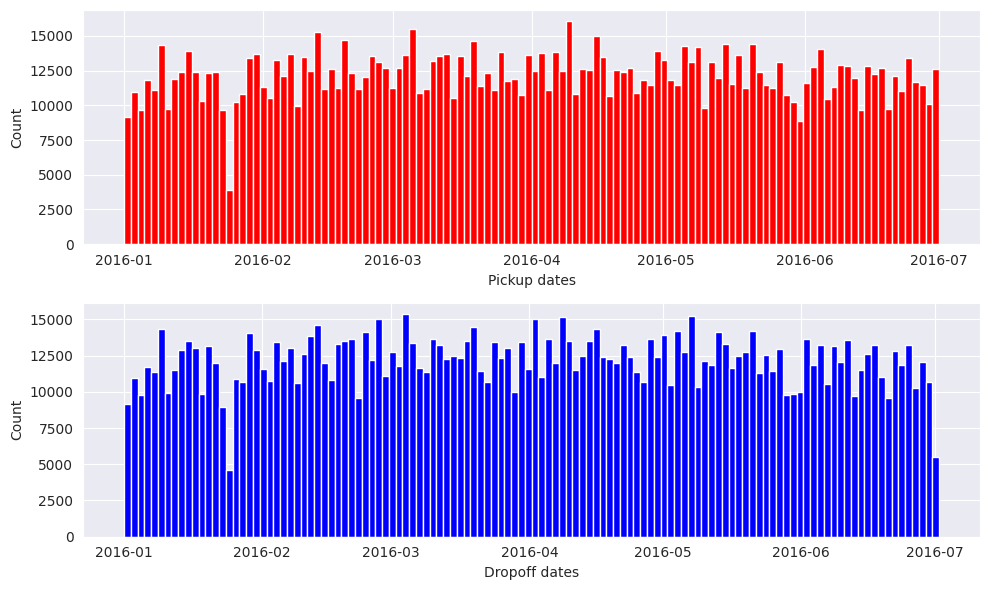

In [39]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=False)

axes[0].hist(df['pickup_datetime'], bins=120, color='red')
axes[0].set_xlabel('Pickup dates')
axes[0].set_ylabel('Count')

axes[1].hist(df['dropoff_datetime'], bins=120, color='blue')
axes[1].set_xlabel('Dropoff dates')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

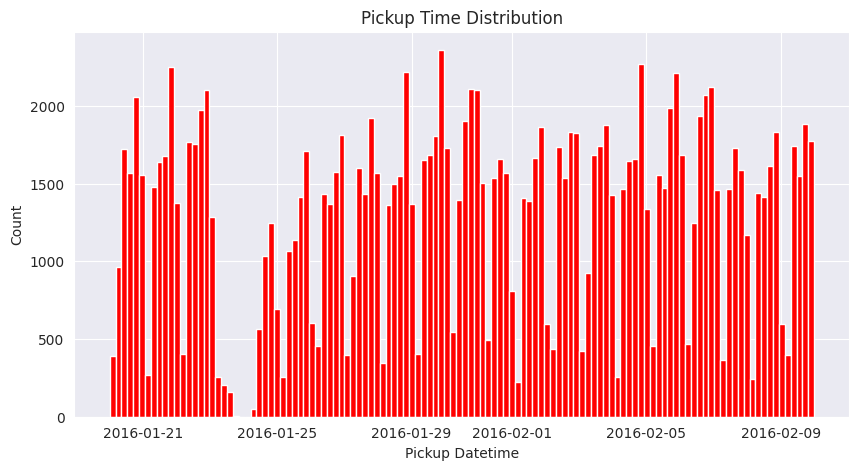

In [40]:
mask = (df['pickup_datetime'] > pd.to_datetime("2016-01-20")) & \
       (df['pickup_datetime'] < pd.to_datetime("2016-02-10"))

filtered_df = df.loc[mask]

plt.figure(figsize=(10, 5))
plt.hist(filtered_df['pickup_datetime'], bins=120, color='red')
plt.xlabel('Pickup Datetime')
plt.ylabel('Count')
plt.title('Pickup Time Distribution')
plt.show()

/tmp/ipykernel_5259/1836726772.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


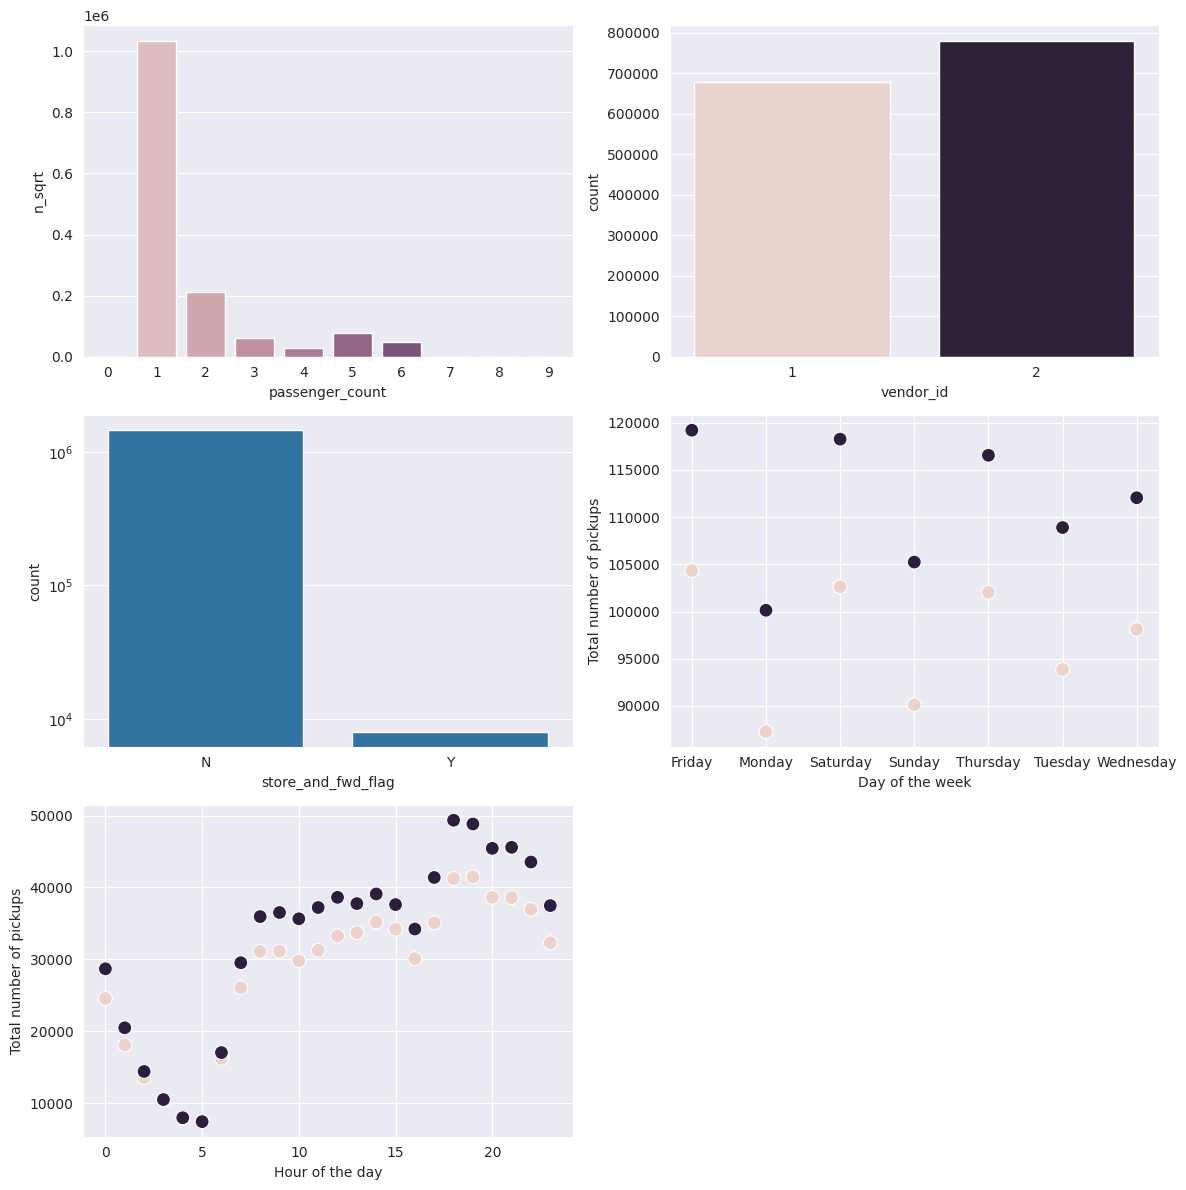

In [42]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# p1: passenger_count distribution (sqrt y-scale)
passenger_counts = df.groupby('passenger_count').size().reset_index(name='n')


passenger_counts['n_sqrt'] = np.sqrt(passenger_counts['n'])
sns.barplot(x='passenger_count', y='n_sqrt', data=passenger_counts,
            hue='passenger_count', dodge=False, ax=axes[0])


sns.barplot(x='passenger_count', y='n', data=passenger_counts,
            hue='passenger_count', dodge=False, ax=axes[0])

#axes[0].set_yscale('sqrt')
axes[0].legend().remove()

# p2: vendor_id count
sns.countplot(x='vendor_id', hue='vendor_id', data=df, ax=axes[1])
axes[1].legend().remove()

# p3: store_and_fwd_flag count (log y-scale)
sns.countplot(x='store_and_fwd_flag', data=df, ax=axes[2])
axes[2].set_yscale('log')
axes[2].legend().remove()

# p4: weekday vs vendor_id counts
df['wday'] = df['pickup_datetime'].dt.day_name()
wday_counts = df.groupby(['wday', 'vendor_id']).size().reset_index(name='n')
sns.scatterplot(x='wday', y='n', hue='vendor_id', data=wday_counts,
                s=100, ax=axes[3])
axes[3].set_xlabel('Day of the week')
axes[3].set_ylabel('Total number of pickups')
axes[3].legend().remove()

# p5: hour vs vendor_id counts
df['hpick'] = df['pickup_datetime'].dt.hour
hpick_counts = df.groupby(['hpick', 'vendor_id']).size().reset_index(name='n')
sns.scatterplot(x='hpick', y='n', hue='vendor_id', data=hpick_counts,
                s=100, ax=axes[4])
axes[4].set_xlabel('Hour of the day')
axes[4].set_ylabel('Total number of pickups')
axes[4].legend().remove()

# Hide empty subplot (bottom right)
axes[5].axis('off')

plt.tight_layout()
plt.show()